# Завдання №1

В якості набору даних буде використано <b>Boston Housing</b> з бібліотеки <b>sklearn.datasets</b><br>

Це набір даних, який містить інформацію про різні аспекти житлового сектора в околицях Бостона, США. Головною метою цього набору даних є прогнозування середньої вартості житла для певних районів.<br>

Основні ознаки у цьому наборі даних включають такі аспекти:<br>

<b>CRIM</b> (crime rate): Кримінальна небезпека в районі.<br>
<b>ZN</b> (proportion of residential land zoned for large lots): Відсоток житлової землі, зонованої для великих ділянок.<br>
<b>INDUS</b> (proportion of non-retail business acres per town): Відсоток площі, призначеної для не-роздрібної торгівлі.<br>
<b>CHAS</b> (Charles River dummy variable): Фіктивна змінна, яка позначає, чи проходить ділянка вздовж річки Чарльз.<br>
<b>NOX</b> (nitric oxides concentration): Концентрація оксидів азоту.<br>
<b>RM</b> (average number of rooms per dwelling): Середня кількість кімнат у житловому приміщенні.<br>
<b>AGE</b> (proportion of owner-occupied units built prior to 1940): Відсоток одиниць, які власники займали до 1940 року.<br>
<b>DIS</b> (weighted distances to five Boston employment centers): Вагові відстані до п'яти центрів зайнятості в Бостоні.<br>
<b>RAD</b> (index of accessibility to radial highways): Індекс доступності до радіальних магістралей.<br>
<b>TAX</b> (full-value property tax rate per $10,000): Повна ставка податку на власність на 10,000<br>
<b>PTRATIO</b> (pupil-teacher ratio by town): Співвідношення учнів до вчителів за містом.<br>
<b>B</b> (1000(Bk - 0.63)^2): Параметр, який пов'язаний із відсотком афроамериканців у населенні.<br>
<b>LSTAT</b> (% lower status of the population): Відсоток населення з низьким соціальним статусом.<br>
<br>Цільова ознака:<br>

<b>MEDV</b> (median value of owner-occupied homes in $1000s): Медіанна вартість житла, власності власників, вимірювана в тисячах доларів США.<br>



---



Карти Кохонена, що самоорганізуються (<b>SOM</b>), є потужним інструментом, який
обʼєднує дві важливі задачі аналізу даних - кластеризація і проектування, тобто
дозволяють здійснити візуалізацію багатомірних даних на площині. Налаштування <b>SOM</b> відноситься до алгоритмів навчання без вчителя.



---



Навчання мережі почнемо з імпортуванні всіх потрібних бібліотек:

In [2]:
!pip install minisom

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from minisom import MiniSom
import matplotlib.pyplot as plt

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.2-py3-none-any.whl size=10650 sha256=2ba8dd07784d35e4775d6261b2300f10bc8a0ebc2f446ab2292d7ad2e3c5a711
  Stored in directory: /root/.cache/pip/wheels/b4/f6/8a/9daf8831901c3e3805775633404248f10663d1c80b7e5a1314
Successfully built minisom




---



Завантажимо набір даних та виведемо колонки. Далі виберемо 7 змінних для кластеризації та стандартизуємо дані.

In [3]:
boston = fetch_openml(name="boston", version=2, as_frame=True)
data_train = boston.frame

# Виведення колонок
print("Columns of data_train:")
print(data_train.columns)

# Вибір 6 змінних для кластеризації
var_names = ["INDUS", "DIS", "NOX", "LSTAT", "AGE", "RAD"]
data_train = data_train[var_names]

# Стандартизація даних(видалення середнього та масштабування до одиниці дисперсії)
scaler = StandardScaler()
data_train_matrix = scaler.fit_transform(data_train)

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Columns of data_train:
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'binaryClass'],
      dtype='object')




---



Задаємо <b>seed</b> для відтворюваності результатів алгоритму <b>SOM</b>

In [4]:
np.random.seed(123)



---



Створимо шестикутну сітку для <b>SOM</b>


In [5]:
grid_size = (9, 6) # Розмір сітки
som = MiniSom(grid_size[0], grid_size[1], data_train.shape[1], sigma=1.0, learning_rate=0.5) # Визначення моделі SOM



---



Тренування моделі <b>SOM</b> та збереження середньої відстані до найближчих нейронів


In [ ]:
num_iterations = 100
average_distances = []

for i in range(num_iterations):
    som.train_batch(data_train_matrix, num_iteration=1, verbose=True)
    # Визначення середньої відстані до найближчих нейронів для кожної ітерації
    distances = som.distance_map().flatten()
    average_distances.append(np.mean(distances))



---



Візуалізація змін середньої відстані до найближчих нейронів

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(range(1, num_iterations + 1), average_distances, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Average Distance to Nearest Neurons')
plt.title('SOM Training Changes')
plt.show()



---



# Завдання №2

Виконаємо візуальне представлення карт Кохонена за різних параметрів, використовуючи набір даних з минулого завдання. Реалізуємо <b>SOM</b> типів <b>"counts"</b> та <b>"quality"</b>.



---



Виконаємо ті ж початкові кроки, що і в минулому завданні:

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from minisom import MiniSom
import matplotlib.pyplot as plt
# lab 6 task 2
# Load Boston dataset
boston = fetch_openml(name="boston", version=2, as_frame=True)
data_train = boston.frame

# Select 6 variables for clustering
var_names = ["INDUS", "DIS", "NOX", "LSTAT", "AGE", "RAD"]
data_train = data_train[var_names]

# Standardize the data
scaler = StandardScaler()
data_train_matrix = scaler.fit_transform(data_train)

# Set seed for reproducibility
np.random.seed(123)

# Create a hexagonal grid for SOM
grid_size = (9, 6)
som_counts = MiniSom(grid_size[0], grid_size[1], data_train.shape[1], sigma=1.0, learning_rate=0.5)
som_quality = MiniSom(grid_size[0], grid_size[1], data_train.shape[1], sigma=1.0, learning_rate=0.5)

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(




---



Впевнемось, що <b>'data_train_matrix'</b> визначено перед навчанням <b>SOM</b> та збиранням середніх відстаней та проведемо навчання моделі <b>SOM</b> для <b>"counts"</b> та <b>"quality"</b> зберігаючи середні відстані до найближчих нейронів:

In [9]:
data_train_matrix = np.array(data_train_matrix)

num_iterations = 100
average_distances_counts = []
average_distances_quality = []

# Тренування моделі SOM
for i in range(num_iterations):
    som_counts.train_batch(data_train_matrix, num_iteration=1, verbose=True)
    distances_counts = som_counts.distance_map().flatten()
    average_distances_counts.append(np.mean(distances_counts))

    som_quality.train_batch(data_train_matrix, num_iteration=1, verbose=True)
    distances_quality = som_quality.distance_map().flatten()
    average_distances_quality.append(np.mean(distances_quality))

 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.5861372379839715
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6512355184387313
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.5751314960562983
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6404271500813818
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.5717914785476959
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.638227593562181
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.5708273685542764
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6382103555878922
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.5707905354924054
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6404775793403181
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.5712617393476058
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.643224092961486
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.572332725872734
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.645795412470

/usr/local/lib/python3.10/dist-packages/minisom.py:540: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.603073614974813
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6671065862510583
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6041499833181085
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6676651911987368
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6051638151910823
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.668216122859188
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6061229237690384
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6687234415051335
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6070471978643182
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.669167905504944
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6078952258096606
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6695408810765202
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.608708665056407
 [ 1 / 1 ] 100% - 0:00:00 left 
 quantization error: 1.6698574989364



---



Реалізуємо виведення результатів:

In [ ]:
# "counts"
plt.figure(figsize=(10, 8))
plt.pcolor(som_counts.distance_map().T, cmap='bone_r', alpha=0.8)
plt.colorbar()
plt.title('SOM Clustering - Counts')
plt.show()

# "quality"
plt.figure(figsize=(10, 8))
plt.pcolor(som_quality.distance_map().T, cmap='bone_r', alpha=0.8)
plt.colorbar()
plt.title('SOM Clustering - Quality')
plt.show()


# Завдання №3

Отримаємо карту розподілу будь-якого показника за його стандартизованою або натуральною шкалою.



---



Початкові кроки залишаються тими ж:

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from minisom import MiniSom
import matplotlib.pyplot as plt

boston = fetch_openml(name="boston", version=2, as_frame=True)
data_train = boston.frame

var_names = ["INDUS", "DIS", "NOX", "LSTAT", "AGE", "RAD", "B"]
data_train = data_train[var_names]

scaler = StandardScaler()
data_train_matrix = scaler.fit_transform(data_train)

np.random.seed(123)

grid_size = (9, 6)
som_model = MiniSom(grid_size[0], grid_size[1], data_train.shape[1], sigma=1.0, learning_rate=0.5)

data_train_matrix = np.array(data_train_matrix)

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(




---



Визначаємо координати найближчого нейрону для кожного запису в навчальному наборі:

In [12]:
bmu_coordinates = np.array([som_model.winner(x) for x in data_train_matrix])



---



Визначення кольорів для кожного нейрону на основі значень <b>"B"</b> (чорних жителів) для кожного запису:

In [13]:
colors = np.where(data_train["B"] <= 100, 1, 0)



---



Візуалізація карти:

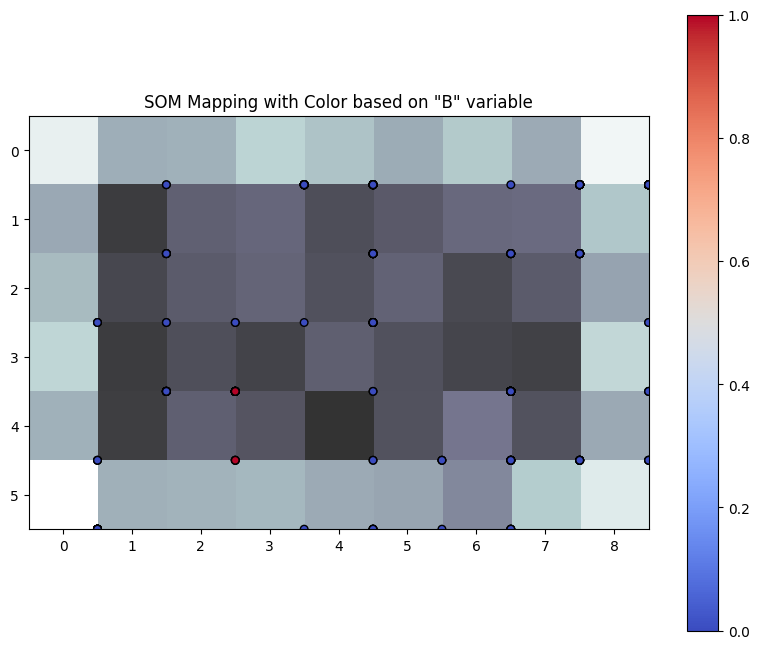

In [14]:
plt.figure(figsize=(10, 8))
plt.imshow(som_model.distance_map().T, cmap='bone_r', alpha=0.8)
plt.scatter(bmu_coordinates[:, 0] + 0.5, bmu_coordinates[:, 1] + 0.5, c=colors, s=30, marker='o', edgecolors='k', cmap='coolwarm')
plt.colorbar()
plt.title('SOM Mapping with Color based on "B" variable')
plt.show()



---



Візуалізація вагових коефіцієнтів для кожної змінної в SOM

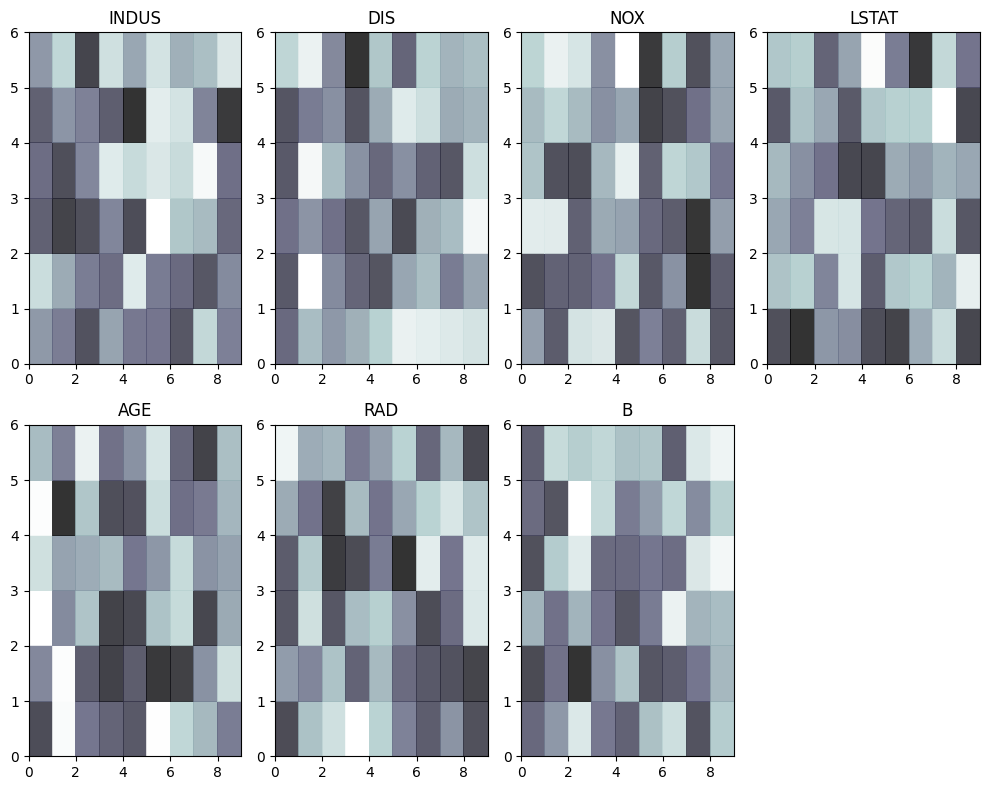

In [15]:
plt.figure(figsize=(10, 8))
for i, var_name in enumerate(var_names):
    plt.subplot(2, 4, i + 1)
    plt.pcolor(som_model.get_weights()[:, :, i].T, cmap='bone_r', alpha=0.8)
    plt.title(var_name)

plt.tight_layout()
plt.show()